# 🔧 Data Preprocessing & Feature Engineering
## Employee Attrition Prediction

**Objective**: Transform raw data into ML-ready features using our reusable pipeline.

**Steps**:
1. Load & clean data
2. Feature engineering — create composite & ratio features
3. Encode categorical variables
4. Train-test split (stratified)
5. Feature scaling (StandardScaler)
6. Smart Hybrid Feature Selection (Filter -> VIF -> Boruta)
7. Handle class imbalance (SMOTE)
8. Confirm pipeline output

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import (
    load_data, encode_target, encode_features, 
    create_features, scale_features, select_features, 
    handle_imbalance, build_pipeline
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Modules loaded ✅')

Modules loaded ✅


## Step 1: Load & Clean

In [2]:
DATA_PATH = '../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv'

df = load_data(DATA_PATH)
print(f'Shape after cleaning: {df.shape}')
print(f'Columns dropped: EmployeeNumber, Over18, StandardHours, EmployeeCount')
df.head()

Shape after cleaning: (1470, 31)
Columns dropped: EmployeeNumber, Over18, StandardHours, EmployeeCount


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


## Step 2: Feature Engineering
Creating intermediate-level features that capture business-meaningful patterns.

In [3]:
df_encoded = encode_target(df)
df_feat = create_features(df_encoded)

# Show the new features
new_features = ['Income_per_Age', 'Years_per_Promotion', 'Satisfaction_Score', 
                'TotalSatisfaction', 'Overtime_Flag', 'Experience_Company_Ratio']
existing_new = [f for f in new_features if f in df_feat.columns]

print('\n📌 New Engineered Features:')
print('='*60)
for feat in existing_new:
    print(f'  • {feat}: mean={df_feat[feat].mean():.3f}, std={df_feat[feat].std():.3f}')

df_feat[existing_new].describe().round(3)


📌 New Engineered Features:
  • Income_per_Age: mean=170.943, std=101.848
  • Years_per_Promotion: mean=0.236, std=0.269
  • Satisfaction_Score: mean=2.721, std=0.628
  • TotalSatisfaction: mean=8.163, std=1.885
  • Overtime_Flag: mean=0.283, std=0.451
  • Experience_Company_Ratio: mean=0.582, std=0.284


,Income_per_Age,Years_per_Promotion,Satisfaction_Score,TotalSatisfaction,Overtime_Flag,Experience_Company_Ratio
count,1470.000,1470.000,1470.000,1470.000,1470.000,1470.000
mean,170.943,0.236,2.721,8.163,0.283,0.582
std,101.848,0.269,0.628,1.885,0.451,0.284
min,36.033,0.000,1.000,3.000,0.000,0.000
25%,93.211,0.000,2.333,7.000,0.000,0.368
50%,140.970,0.143,2.667,8.000,0.000,0.636
75%,223.466,0.429,3.333,10.000,1.000,0.833
max,556.000,0.917,4.000,12.000,1.000,0.976


## Step 3 & 4: Encoding & Splitting

In [4]:
from sklearn.model_selection import train_test_split

# Encode categoricals
df_final = encode_features(df_feat)

X = df_final.drop(columns=['Attrition'])
y = df_final['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

X_train shape: (1176, 48) | X_test shape: (294, 48)

## Step 5: Feature Scaling

In [5]:
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

print("Feature means after scaling (should be ~0):")
print(X_train_scaled.mean().head(5).round(3))

Feature means after scaling (should be ~0):
Age                -0.0
BusinessTravel     -0.0
DailyRate           0.0
DistanceFromHome   -0.0
Education           0.0
dtype: float64


### 6.1: Correlation Filtering
Removing features that have almost zero ( < 0.05) relationship with our target (`Attrition`). This is a fast, computationally inexpensive 'sanity check'.

In [6]:
# Calculate absolute correlation with target
corr = X_train_scaled.corrwith(y_train).abs()
valid_corr = corr[corr >= 0.05].index.tolist()

print(f"Initial Features: {X_train_scaled.shape[1]}")
print(f"Remaining after Correlation (>0.05) Filter: {len(valid_corr)}")

dropped = set(X_train_scaled.columns) - set(valid_corr)
print(f"Dropped: {list(dropped)[:5]}..." if len(dropped) > 5 else f"Dropped: {list(dropped)}")

Initial Features: 48


Remaining after Correlation (>0.05) Filter: 31
Dropped: ['MonthlyRate', 'EducationField_Technical Degree', 'RelationshipSatisfaction', 'TrainingTimesLastYear', 'EducationField_Medical']...


### 6.2: Multicollinearity Check (VIF)
Features that are highly correlated with *each other* (not the target) provide redundant information and can inflate coefficients in linear models. We remove any feature with a **Variance Inflation Factor (VIF) > 10**.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = valid_corr.copy()
X_filtered = X_train_scaled[vif_features]

while True:
    vif_values = [variance_inflation_factor(X_filtered[vif_features].values, i) 
                  for i in range(len(vif_features))]
    if not vif_values: break
    max_vif = max(vif_values)
    
    if max_vif > 10:
        idx = vif_values.index(max_vif)
        print(f"Dropping '{vif_features[idx]}' with VIF = {max_vif:.2f}")
        vif_features.pop(idx)
    else:
        break

print(f"\nFeatures remaining after VIF Filter: {len(vif_features)}")

Dropping 'Satisfaction_Score' with VIF = inf


Dropping 'MonthlyIncome' with VIF = 64.60


Dropping 'JobLevel' with VIF = 10.35



Features remaining after VIF Filter: 28


### 6.3: Boruta Feature Wrapper
Boruta is a robust all-relevant feature selection wrapper around a Random Forest. It competes each real feature against a 'shadow' (shuffled) version to prove it has true predictive power.

In [8]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)
boruta_selector = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42)

# Boruta fit expects numpy arrays
boruta_selector.fit(X_train_scaled[vif_features].values, y_train.values)

# Extract selected features (Confirmed + Tentative)
boruta_features = []
for i, is_selected in enumerate(boruta_selector.support_):
    if is_selected: boruta_features.append(vif_features[i])
for i, is_weak in enumerate(boruta_selector.support_weak_):
    if is_weak: boruta_features.append(vif_features[i])

print(f"Boruta identified {len(boruta_features)} significant features.")

Boruta identified 10 significant features.


### 6.4: Final Pruning to Top 20
If Boruta finds more features than we need, we use a standard Random Forest importance to select the 'best' among the relevant ones.

In [9]:
# Final selection using actual function from our module
# This encapsulates the logic we just manually verified
selected_features = select_features(X_train_scaled, y_train, top_n=20)

X_train_selected = X_train_scaled[selected_features]
X_test_selected = X_test_scaled[selected_features]

print(f'\n✅ Final Feature Count: {X_train_selected.shape[1]}')
pd.Series(selected_features, name="Selected Features").to_frame().head(10)


Performing Smart Hybrid Feature Selection...
1. Filtering by Correlation (> 0.05): 31 features remain.
2. Checking VIF (removing VIF > 10)...


   Features remaining after VIF filter: 28
3. Running Boruta Feature Selection...


   Boruta selected 10 features (Confirmed + Tentative).
   Boruta selected 10 features. Padding up to 15 features using RF importance.



Final Top 15 Features selected:
  1. Age
  2. DailyRate
  3. StockOptionLevel
  4. TotalWorkingYears
  5. YearsAtCompany

✅ Final Feature Count: 15


,Selected Features
0,Age
1,DailyRate
2,StockOptionLevel
3,TotalWorkingYears
4,YearsAtCompany
5,YearsWithCurrManager
6,Income_per_Age
7,TotalSatisfaction
8,Overtime_Flag
9,Experience_Company_Ratio


## Step 7: Handle Imbalance (SMOTE)
Applied *only* to training data *after* feature selection.

Before SMOTE: {0: 986, 1: 190}
After SMOTE:  {0: 986, 1: 986}


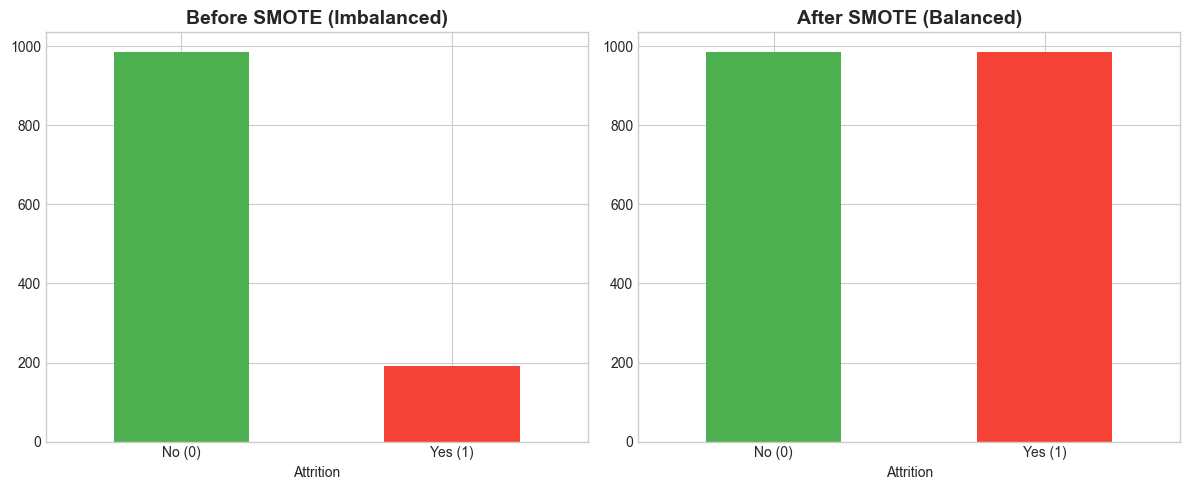

In [10]:
X_train_resampled, y_train_resampled = handle_imbalance(X_train_selected, y_train, random_state=42)

# Visualizing SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], ax=axes[0])
axes[0].set_title('Before SMOTE (Imbalanced)', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

y_train_resampled.value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'], ax=axes[1])
axes[1].set_title('After SMOTE (Balanced)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)

plt.tight_layout()
plt.savefig('../outputs/smote_demonstration.png', dpi=150, bbox_inches='tight')
plt.show()

## 🚀 All-in-One Pipeline Execution
Testing our wrapper function that does all of the above in one go.

In [11]:
pipeline_data = build_pipeline(DATA_PATH, apply_smote=True, apply_scaling=True, apply_selection=True, top_n_features=20)

pd.Series(pipeline_data['feature_names']).to_frame("Final Top 20 Features")


Performing Smart Hybrid Feature Selection...
1. Filtering by Correlation (> 0.05): 31 features remain.
2. Checking VIF (removing VIF > 10)...


   Features remaining after VIF filter: 28
3. Running Boruta Feature Selection...


   Boruta selected 10 features (Confirmed + Tentative).
   Boruta selected 10 features. Padding up to 15 features using RF importance.



Final Top 15 Features selected:
  1. Age
  2. DailyRate
  3. StockOptionLevel
  4. TotalWorkingYears
  5. YearsAtCompany
Before SMOTE: {0: 986, 1: 190}
After SMOTE:  {0: 986, 1: 986}

OK: Pipeline complete!
   Training samples: 1972 | Test samples: 294
   Features: 15


,Final Top 20 Features
0,Age
1,DailyRate
2,StockOptionLevel
3,TotalWorkingYears
4,YearsAtCompany
5,YearsWithCurrManager
6,Income_per_Age
7,TotalSatisfaction
8,Overtime_Flag
9,Experience_Company_Ratio
